## Breast Cancer Detection with CNN

Project found in: https://github.com/Dikshyant15/ML_individual_assignment/tree/main

Because the tumors themselves only make up a small percentage of the image of the entire breast, detecting breast cancer on screening mammography is difficult as an image classification task. A potentially malignant region of interest (ROI) can be as small as 100 x 100 pixels, but a full-field digital mammography (FFDM) image is usually 4000 x 3000 pixels.

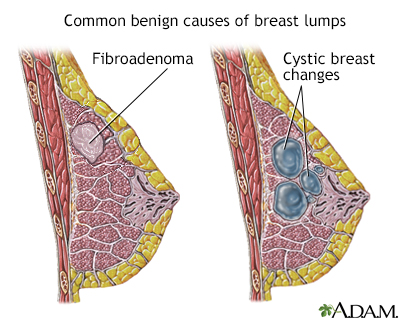

This explains why there are so many photos in the data—more than a quarter of a million!

Our objective is to determine whether or not a patient's patch of tissue slice includes IDC.

In [ ]:
!pip install kagglehub

## Importing the data set

The dataset for this project consists of breast histopathology photos, or biopsy images stained with Hematoxylin and Eosin (H&E), which highlight cellular features. The data set is extracted via the Kaggle API where, each image is a 50×50 pixel patch from larger whole-slide images, capturing critical local tissue structures. These details are vital for differentiating normal from cancerous tissue, though their complexity can make interpretation challenging.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")

print("Dataset path:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Dataset path: /kaggle/input/breast-histopathology-images


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/breast-histopathology-images


In [ ]:
import os
import numpy as np
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


from skimage.filters import gaussian
from skimage.util import random_noise
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.manifold import TSNE


import tensorflow as tf
from tensorflow.keras import layers, Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import model_from_json
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D,Dropout,MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint







## Adjusting Data

In order to have a organisational and a easier dataset to process, we will prefer to extract the data into a tensor and then iterate into each image file to convert it into a pandas data frame.

In [ ]:
# accsess the data files and dir
# cancer_rays_dir     = os.listdir("../input/breast-histopathology-images/IDC_regular_ps50_idx5")
# all_rays_dir        = "all_rays_dir"  # is this path we will put all the images
# cancer_rays_dir_str ="../input/breast-histopathology-images/IDC_regular_ps50_idx5/"

import tensorflow as tf

cancer_rays_dir = tf.keras.utils.image_dataset_from_directory(
    path,
    image_size=(50,50),
    batch_size=32
)

Found 555048 files belonging to 280 classes.


In [ ]:
print(cancer_rays_dir)
print(len(cancer_rays_dir))

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 50, 50, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
17346


In [ ]:
# original dataset root
data_root = os.path.join(path, "IDC_regular_ps50_idx5")

filepaths = []
labels = []

# walk through each patient folder
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)

    if not os.path.isdir(patient_path):
        continue

    for label in ["0", "1"]:
        label_path = os.path.join(patient_path, label)

        if not os.path.exists(label_path):
            continue

        for fname in os.listdir(label_path):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                filepaths.append(os.path.join(label_path, fname))
                labels.append(int(label))

# create dataframe
data = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print(data.head())
print(data["label"].value_counts())
print("Total images:", len(data))

                                            filepath  label
0  /kaggle/input/breast-histopathology-images/IDC...      0
1  /kaggle/input/breast-histopathology-images/IDC...      0
2  /kaggle/input/breast-histopathology-images/IDC...      0
3  /kaggle/input/breast-histopathology-images/IDC...      0
4  /kaggle/input/breast-histopathology-images/IDC...      0
label
0    198738
1     78786
Name: count, dtype: int64
Total images: 277524


In [ ]:
data

,filepath,label
0,/kaggle/input/breast-histopathology-images/IDC...,0
1,/kaggle/input/breast-histopathology-images/IDC...,0
2,/kaggle/input/breast-histopathology-images/IDC...,0
3,/kaggle/input/breast-histopathology-images/IDC...,0
4,/kaggle/input/breast-histopathology-images/IDC...,0
...,...,...
277519,/kaggle/input/breast-histopathology-images/IDC...,1
277520,/kaggle/input/breast-histopathology-images/IDC...,1
277521,/kaggle/input/breast-histopathology-images/IDC...,1
277522,/kaggle/input/breast-histopathology-images/IDC...,1


In [ ]:
def extract_target(x):
    return int(x.split('/')[-2])   # second last folder = label

data['target'] = data['filepath'].apply(extract_target)
data.head()

,filepath,label,target
0,/kaggle/input/breast-histopathology-images/IDC...,0,0
1,/kaggle/input/breast-histopathology-images/IDC...,0,0
2,/kaggle/input/breast-histopathology-images/IDC...,0,0
3,/kaggle/input/breast-histopathology-images/IDC...,0,0
4,/kaggle/input/breast-histopathology-images/IDC...,0,0


In [ ]:

def extract_patient_id(x):
    return x.split('/')[-3]   # third last folder = patient id

data['patient_id'] = data['filepath'].apply(extract_patient_id)
data.head()

,filepath,label,target,patient_id
0,/kaggle/input/breast-histopathology-images/IDC...,0,0,10295
1,/kaggle/input/breast-histopathology-images/IDC...,0,0,10295
2,/kaggle/input/breast-histopathology-images/IDC...,0,0,10295
3,/kaggle/input/breast-histopathology-images/IDC...,0,0,10295
4,/kaggle/input/breast-histopathology-images/IDC...,0,0,10295


In [ ]:
data['target'].value_counts()

,count
target,
0,198738
1,78786


## Expoloratory Data Analysis

Exploring the dataset and printing the sample images.

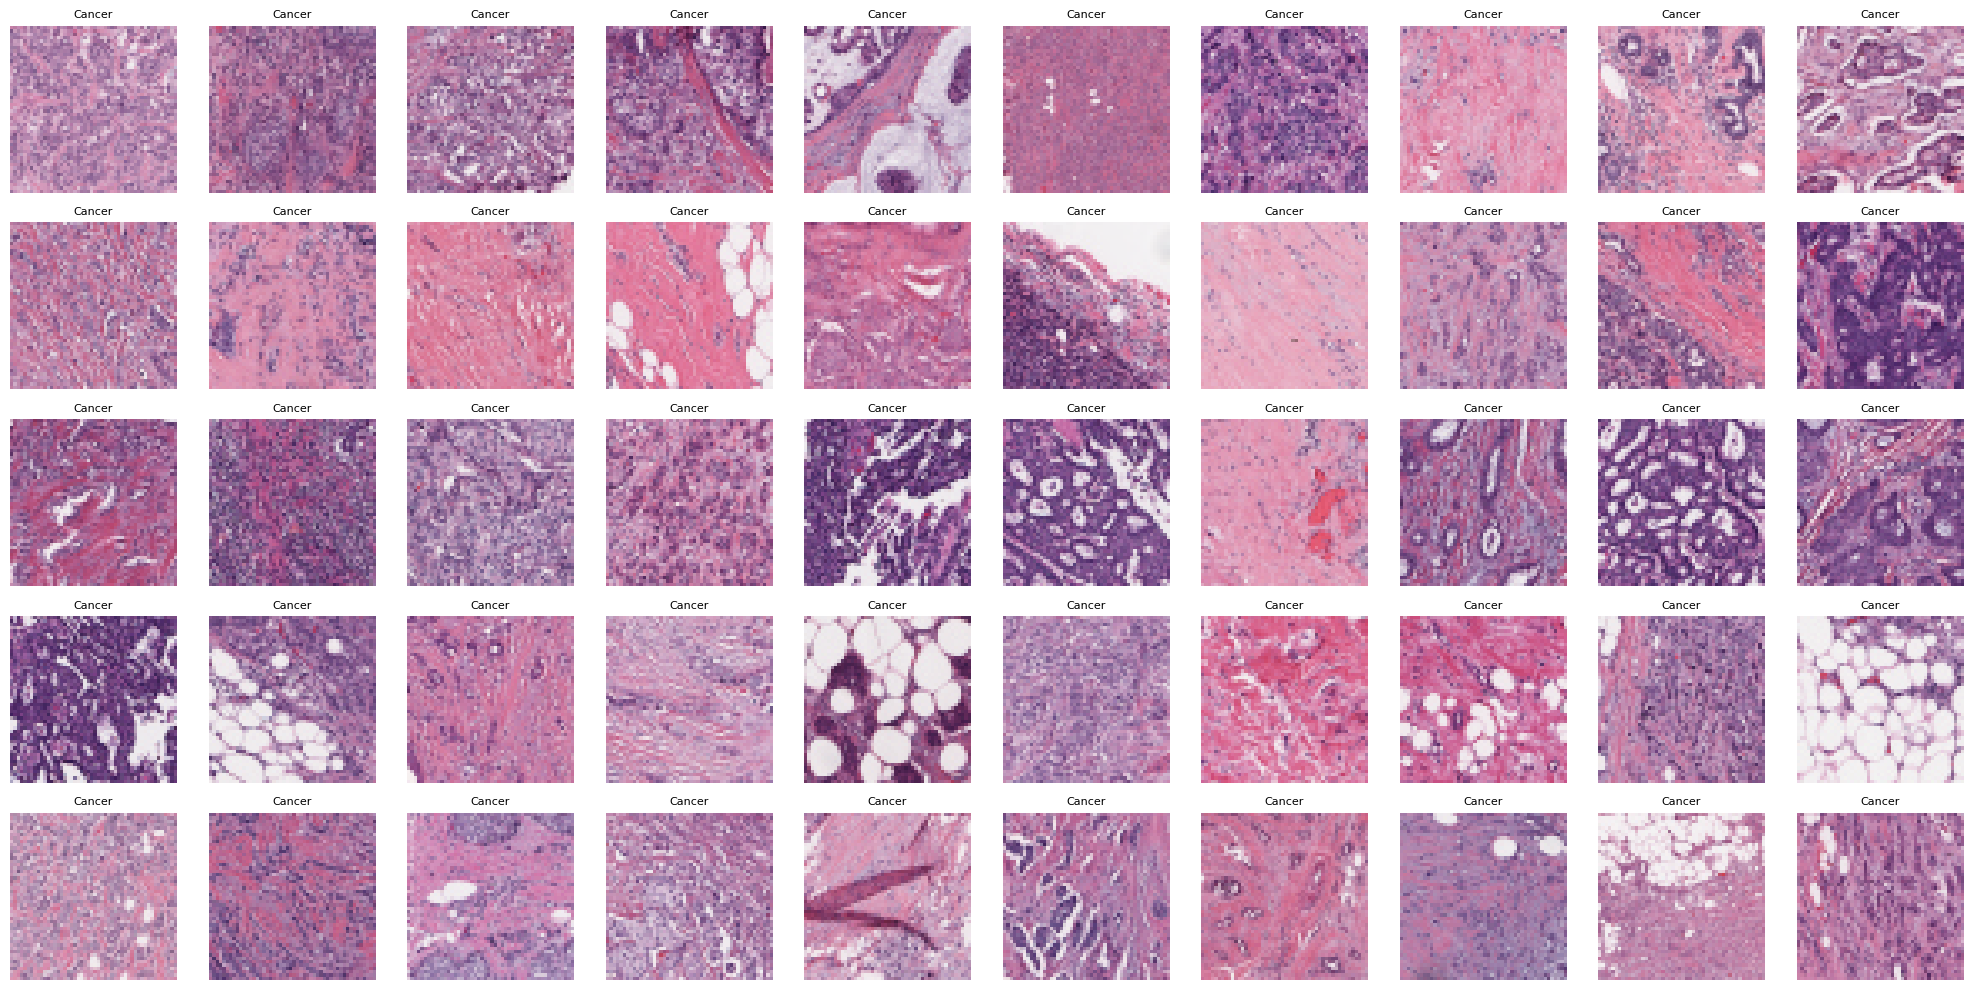

In [ ]:
# Cancer
data['target'] = data['target'].astype(int)

# select samples
pos_selection = np.random.choice(
    data[data.target == 1].index, size=50, replace=False
)

neg_selection = np.random.choice(
    data[data.target == 0].index, size=50, replace=False
)

# plot
fig, ax = plt.subplots(5, 10, figsize=(20, 10))

for n in range(5):
    for m in range(10):
        idx = pos_selection[m + 10*n]

        # directly use filepath
        path = data.loc[idx, 'filepath']

        image = mpimg.imread(path)
        ax[n, m].imshow(image)
        ax[n, m].set_title("Cancer", fontsize=8)
        ax[n, m].axis('off')

plt.tight_layout()
plt.show()

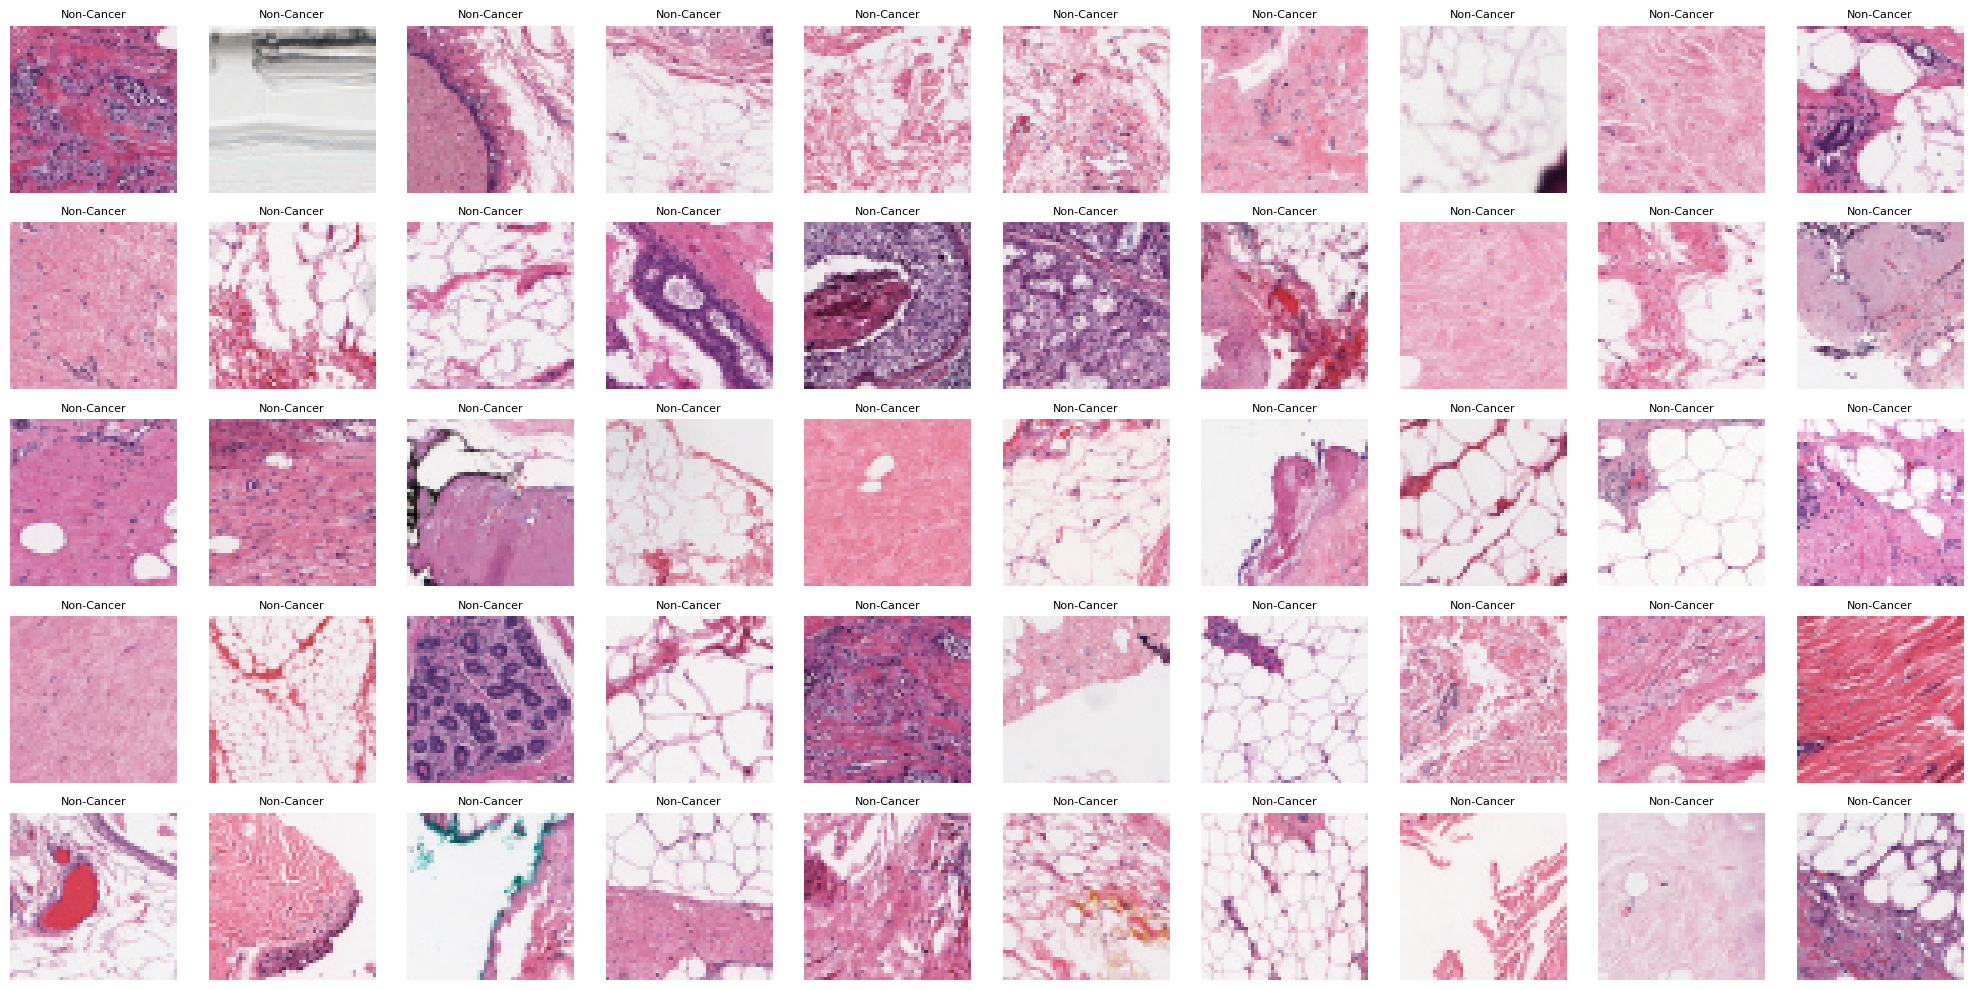

In [ ]:
#NON Cancer
data['target'] = data['target'].astype(int)

# select samples
pos_selection = np.random.choice(
    data[data.target == 1].index, size=50, replace=False
)

neg_selection = np.random.choice(
    data[data.target == 0].index, size=50, replace=False
)

# plot
fig, ax = plt.subplots(5, 10, figsize=(20, 10))

for n in range(5):
    for m in range(10):
        idx = neg_selection[m + 10*n]

        # directly use filepath
        path = data.loc[idx, 'filepath']

        image = mpimg.imread(path)
        ax[n, m].imshow(image)
        ax[n, m].set_title("Non-Cancer", fontsize=8)
        ax[n, m].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_25496/3944380407.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


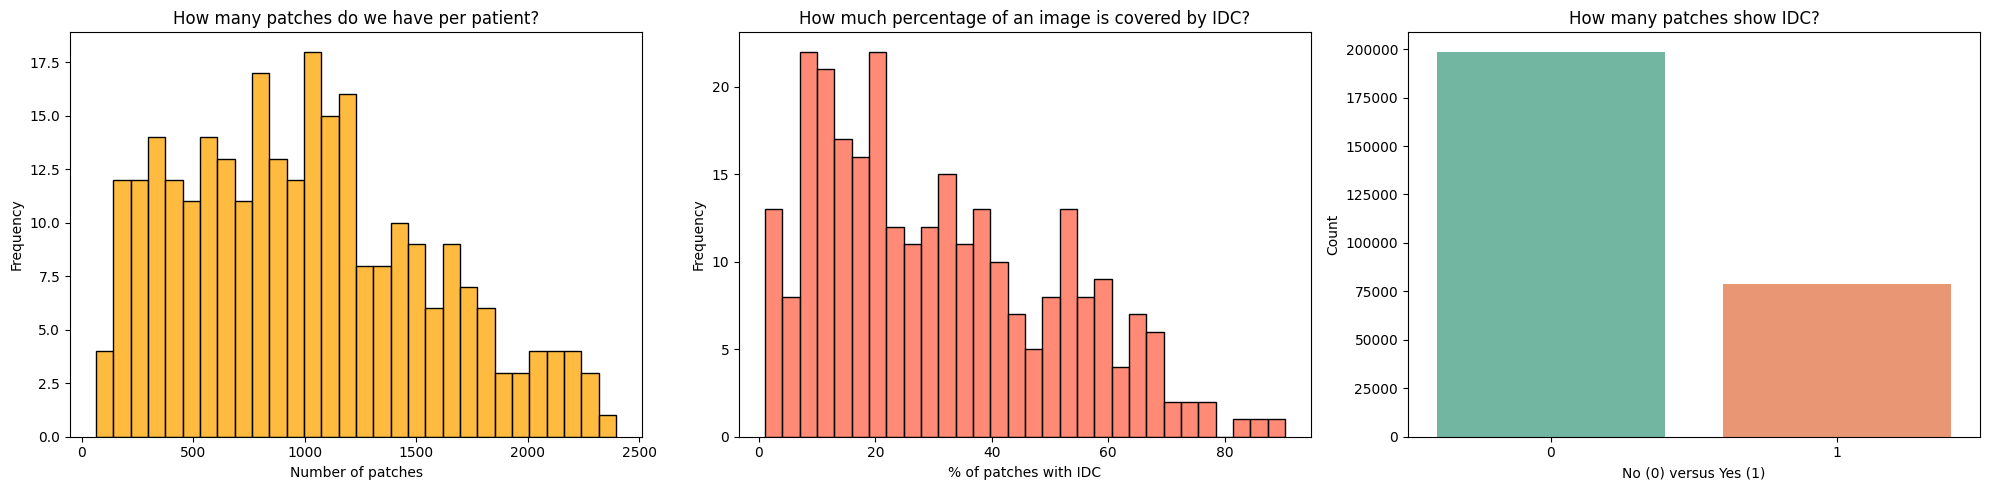

In [ ]:
# percentage of class 0 and 1 per patient
cancer_perc = (
    data.groupby("patient_id")["target"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# 1. number of patches per patient
sns.histplot(
    data.groupby("patient_id").size(),
    ax=ax[0],
    bins=30,
    color="orange"
)
ax[0].set_xlabel("Number of patches")
ax[0].set_ylabel("Frequency")
ax[0].set_title("How many patches do we have per patient?")

# 2. percentage of IDC patches per patient
sns.histplot(
    cancer_perc[1] * 100 if 1 in cancer_perc.columns else [],
    ax=ax[1],
    bins=30,
    color="tomato"
)
ax[1].set_title("How much percentage of an image is covered by IDC?")
ax[1].set_ylabel("Frequency")
ax[1].set_xlabel("% of patches with IDC")

# 3. class distribution
sns.countplot(
    x=data["target"],
    palette="Set2",
    ax=ax[2]
)
ax[2].set_xlabel("No (0) versus Yes (1)")
ax[2].set_ylabel("Count")
ax[2].set_title("How many patches show IDC?")

plt.tight_layout()
plt.show()

## Auto Encoder and CNN Model building

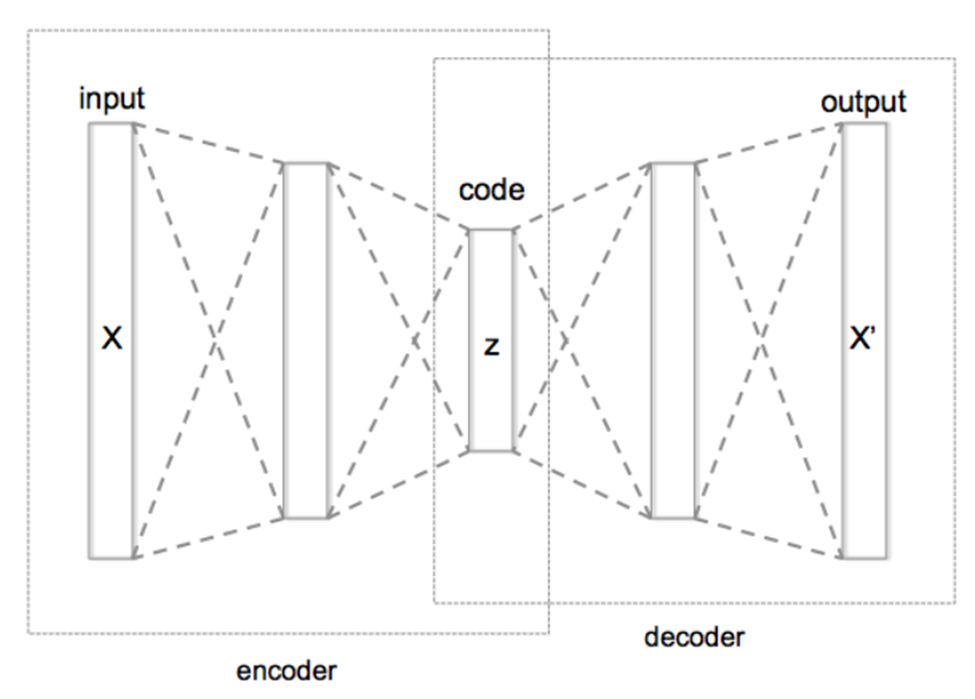

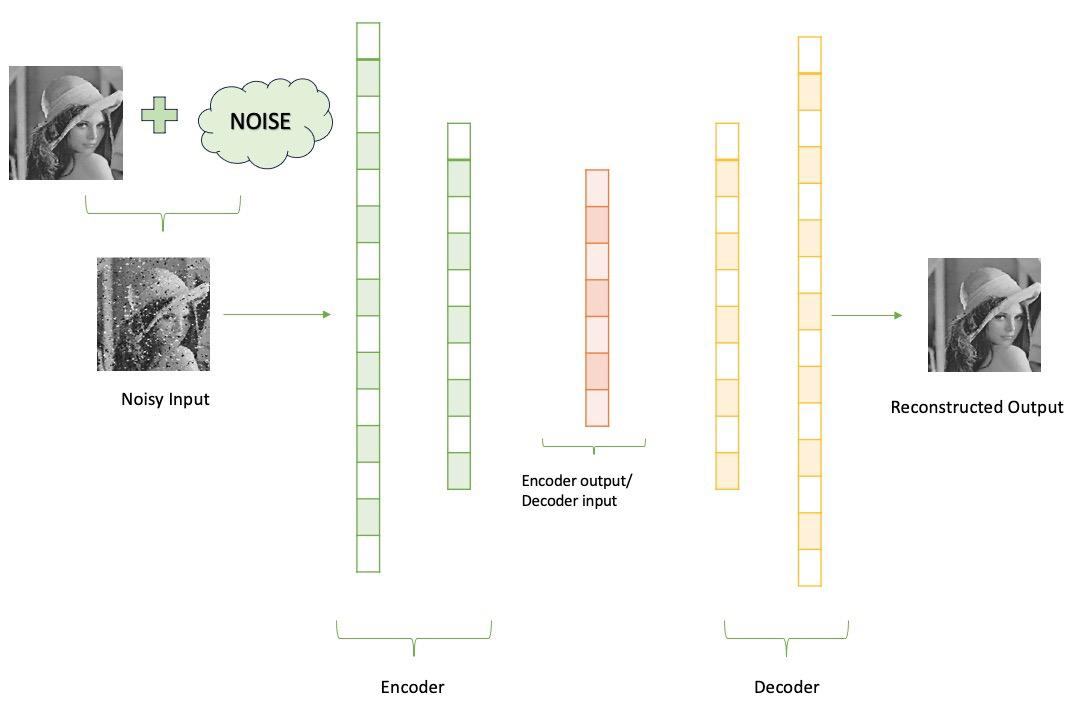

This diagram illustrates the working principle of the denoising autoencoder that will be implemented in this project for breast cancer image analysis. The process begins by taking a clean histopathology image and artificially adding noise to simulate real-world imperfections. This noisy image is then passed through the encoder, which consists of convolutional and pooling layers that progressively compress the image into a lower-dimensional latent representation. This latent space captures the most important structural features of the tissue while discarding irrelevant noise. The compressed representation is then fed into the decoder, which reconstructs the image by upsampling and refining these features. The model is trained to minimise the difference between the reconstructed output and the original clean image, forcing it to learn meaningful, noise-resistant features. In this project, the learned encoder is later reused as a feature extractor for classification, enabling improved detection of cancerous patterns by focusing on essential tissue characteristics rather than noisy variations.

## Mathematical Intuition

1. Denoising Autoencoder

The autoencoder learns a mapping:

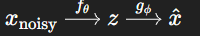

The objective is to minimise reconstruction loss (binary crossentropy for normalised pixels):
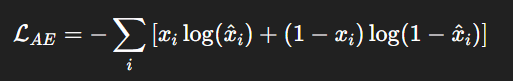


2. Convolutional Feature Extraction

Each convolutional layer computes:
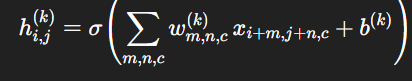

Classifier on Latent Features

The classifier operates on encoded features:

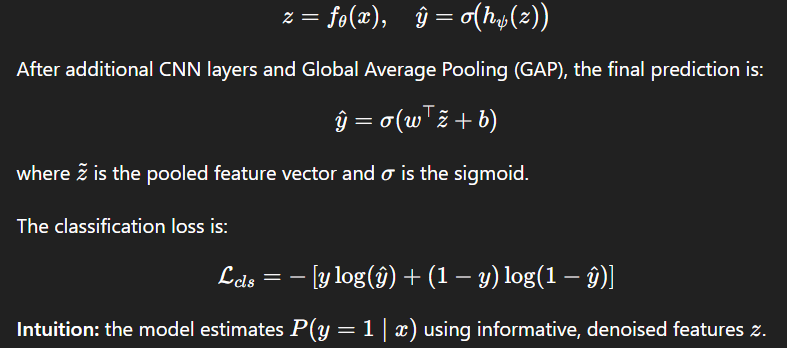

Global Average Pooling (GAP)

GAP converts feature maps to a vector by averaging spatial dimensions:


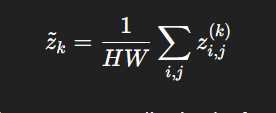


Fine-Tuning
Initially,
θ (encoder) is frozen. During fine-tuning:

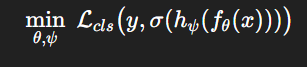

with a small learning rate to adjust features without destroying learned structure.




                                            filepath  label  target patient_id
0  /kaggle/input/breast-histopathology-images/IDC...      0       0      10295
1  /kaggle/input/breast-histopathology-images/IDC...      0       0      10295
2  /kaggle/input/breast-histopathology-images/IDC...      0       0      10295
3  /kaggle/input/breast-histopathology-images/IDC...      0       0      10295
4  /kaggle/input/breast-histopathology-images/IDC...      0       0      10295
target
0    198738
1     78786
Name: count, dtype: int64
Unique patients: 279

Train label distribution:
target
0    0.704489
1    0.295511
Name: proportion, dtype: float64

Val label distribution:
target
0    0.765857
1    0.234143
Name: proportion, dtype: float64

Test label distribution:
target
0    0.720494
1    0.279506
Name: proportion, dtype: float64


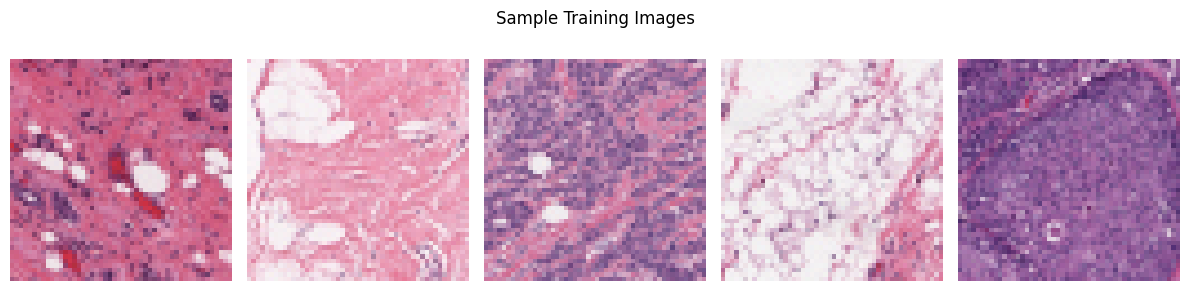

In [ ]:
# ------------------------------
# Reproducibility
# ------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================
# 2. Your dataframe should already exist
#    Expected columns:
#    filepath, label, target, patient_id
# ==============================
print(data.head())
print(data["target"].value_counts())
print("Unique patients:", data["patient_id"].nunique())

# ==============================
# 3. Patient-level train/val/test split
# ==============================

patient_ids = data["patient_id"].unique()
train_ids, temp_ids = train_test_split( patient_ids , test_size=0.30, random_state=SEED)
valid_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED)

train_df = data[data['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = data[data['patient_id'].isin(valid_ids)].reset_index(drop=True)
test_df = data[data['patient_id'].isin(test_ids)].reset_index(drop=True)


print("\nTrain label distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nVal label distribution:")
print(val_df["target"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["target"].value_counts(normalize=True))

# ==============================
# 4. Parameters
# ==============================
IMG_HEIGHT = 50
IMG_WIDTH = 50
CHANNELS = 3
BATCH_SIZE = 32
AUTOENCODER_EPOCHS = 15
CLASSIFIER_EPOCHS = 15
FINE_TUNE_EPOCHS = 8

AUTOTUNE = tf.data.AUTOTUNE

# ==============================
# 5. Image loading functions
# ==============================
def decode_img(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels = 3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_image_label(filepath,label):
  img  = decode_img(filepath)
  label = tf.cast(label, tf.float32)
  return img, label

def add_noise(img, noise_factor=0.08):
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=noise_factor)
    noisy = img + noise
    noisy = tf.clip_by_value(noisy, 0.0, 1.0)
    return noisy

# ==============================
# 6. Build tf.data datasets
# ==============================
def make_classifier_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"].values, df["target"].values)
    )
    ds = ds.map(load_image_label, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def make_autoencoder_dataset(df, shuffle=False, denoising=True):
    ds = tf.data.Dataset.from_tensor_slices(df["filepath"].values)

    def process(filepath):
        img = decode_img(filepath)
        if denoising:
            noisy_img = add_noise(img, noise_factor=0.08)
            return noisy_img, img
        return img, img

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_cls_ds = make_classifier_dataset(train_df, shuffle=True)
val_cls_ds   = make_classifier_dataset(val_df, shuffle=False)
test_cls_ds  = make_classifier_dataset(test_df, shuffle=False)

train_ae_ds = make_autoencoder_dataset(train_df, shuffle=True, denoising=True)
val_ae_ds   = make_autoencoder_dataset(val_df, shuffle=False, denoising=True)


# ==============================
# 7. Visualize some samples
# ==============================
sample_paths = train_df["filepath"].sample(5, random_state=SEED).tolist()

plt.figure(figsize=(12, 3))
for i, fp in enumerate(sample_paths, 1):
    img = decode_img(fp).numpy()
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()






Now we implement a convolutional denoising autoencoder designed to learn meaningful representations from image data. The process begins with an input image of size (IMG_HEIGHT × IMG_WIDTH × CHANNELS), which is passed through the encoder. The encoder consists of stacked convolutional layers with ReLU activation that extract features, followed by max-pooling layers that progressively reduce the spatial dimensions. As the image moves through the encoder, it is compressed into a compact latent representation of size 7×7×128, which captures the most important structural patterns while discarding noise.

The decoder then reconstructs the image from this latent space. It uses convolutional layers to refine features and UpSampling2D layers to gradually restore the spatial resolution. Since upsampling slightly increases the output size beyond the original dimensions, a Cropping2D layer is applied to match the original image size. Finally, a convolutional layer with sigmoid activation produces the reconstructed image with pixel values in the range [0,1]

## Build Auto Encoder

In [ ]:
input_img = layers.Input(shape=(IMG_HEIGHT,IMG_WIDTH,CHANNELS), name='input_image')

# Encoder
x = layers.Conv2D(32, 3, activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D(2, padding="same")(x)   # 25x25x32

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)   # 13x13x64

x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(2, padding="same", name="encoded_features")(x)  # 7x7x128





## Build Decoder

In [ ]:
x = layers.Conv2D(128,3, activation='relu', padding = "same")(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu', padding="same")(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)   # 56x56x32

x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
x = layers.Cropping2D(((3, 3), (3, 3)))(x)     # back to 50x50x16

decoded = layers.Conv2D(3, 3, activation="sigmoid", padding="same", name="decoded_image")(x)



In [ ]:
#build autoencoder
autoencoder = Model(input_img, decoded, name="autoencoder")
autoencoder.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics=["mae"]
)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_features (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded_image (Conv2D)          │ (None, 50, 50, 3)      │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,147 (1.29 MB)

 Trainable params: 338,147 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Now we train the autoencoder to learn how to reconstruct clean images from noisy inputs. The model is trained using the fit() function, where it is provided with a training dataset (train_ae_ds) and a validation dataset (val_ae_ds) to monitor performance on unseen data. During training, the autoencoder learns to minimise the reconstruction loss by adjusting its weights so that the output image becomes as close as possible to the original clean image.

To improve training stability and prevent overfitting, two important callbacks are used. The EarlyStopping callback monitors the validation loss and stops training if it does not improve for a specified number of epochs (patience=4). This ensures that the model does not continue training once it stops learning meaningful patterns, which helps avoid overfitting and saves computational resources. Additionally, restore_best_weights=True ensures that the model retains the best-performing weights rather than the final ones.

The ModelCheckpoint callback saves the model whenever there is an improvement in validation loss. This guarantees that the best version of the autoencoder is preserved during training, even if later epochs degrade performance.

## Train autoencoder model

In [ ]:
# ==============================
# 9. Train Autoencoder
# ==============================
ae_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_autoencoder.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_ae = autoencoder.fit(
    train_ae_ds,
    validation_data=val_ae_ds,
    epochs=AUTOENCODER_EPOCHS,
    callbacks=ae_callbacks
)


Epoch 1/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 461s 74ms/step - loss: 0.5140 - mae: 0.0539 - val_loss: 0.5044 - val_mae: 0.0453
Epoch 2/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 439s 72ms/step - loss: 0.5099 - mae: 0.0469 - val_loss: 0.5034 - val_mae: 0.0430
Epoch 3/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 213s 34ms/step - loss: 0.5089 - mae: 0.0452 - val_loss: 0.5029 - val_mae: 0.0423
Epoch 4/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 189s 31ms/step - loss: 0.5085 - mae: 0.0443 - val_loss: 0.5024 - val_mae: 0.0415
Epoch 5/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 142s 23ms/step - loss: 0.5082 - mae: 0.0437 - val_loss: 0.5022 - val_mae: 0.0408
Epoch 6/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 142s 23ms/step - loss: 0.5079 - mae: 0.0433 - val_loss: 0.5020 - val_mae: 0.0404
Epoch 7/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 150s 24ms/step - loss: 0.5078 - mae: 0.0429 - val_loss: 0.5020 - val_mae: 0.0409
Epoch 8/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 147s 24ms/step - loss: 0.5077 - mae: 0.0427 - val_loss: 0.5018 - val_mae: 0.0401
Epoch 9/15
6042/

In [ ]:
print(history_ae)

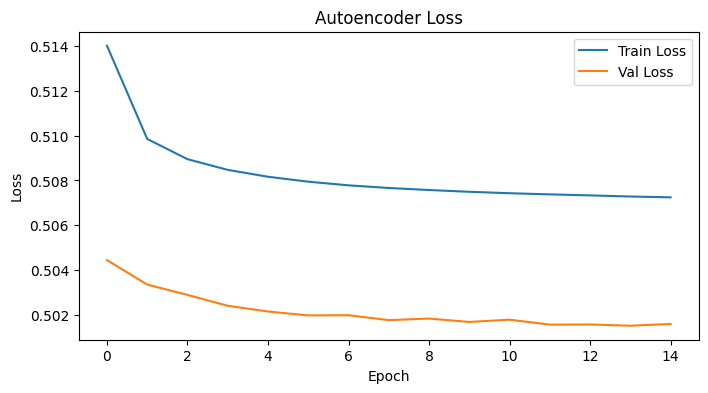

In [ ]:
#plot Autoencoder training
plt.figure(figsize=(8,4))
plt.plot(history_ae.history['loss'], label = "Train Loss")
plt.plot(history_ae.history['val_loss'], label = "Val Loss")
plt.title("Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

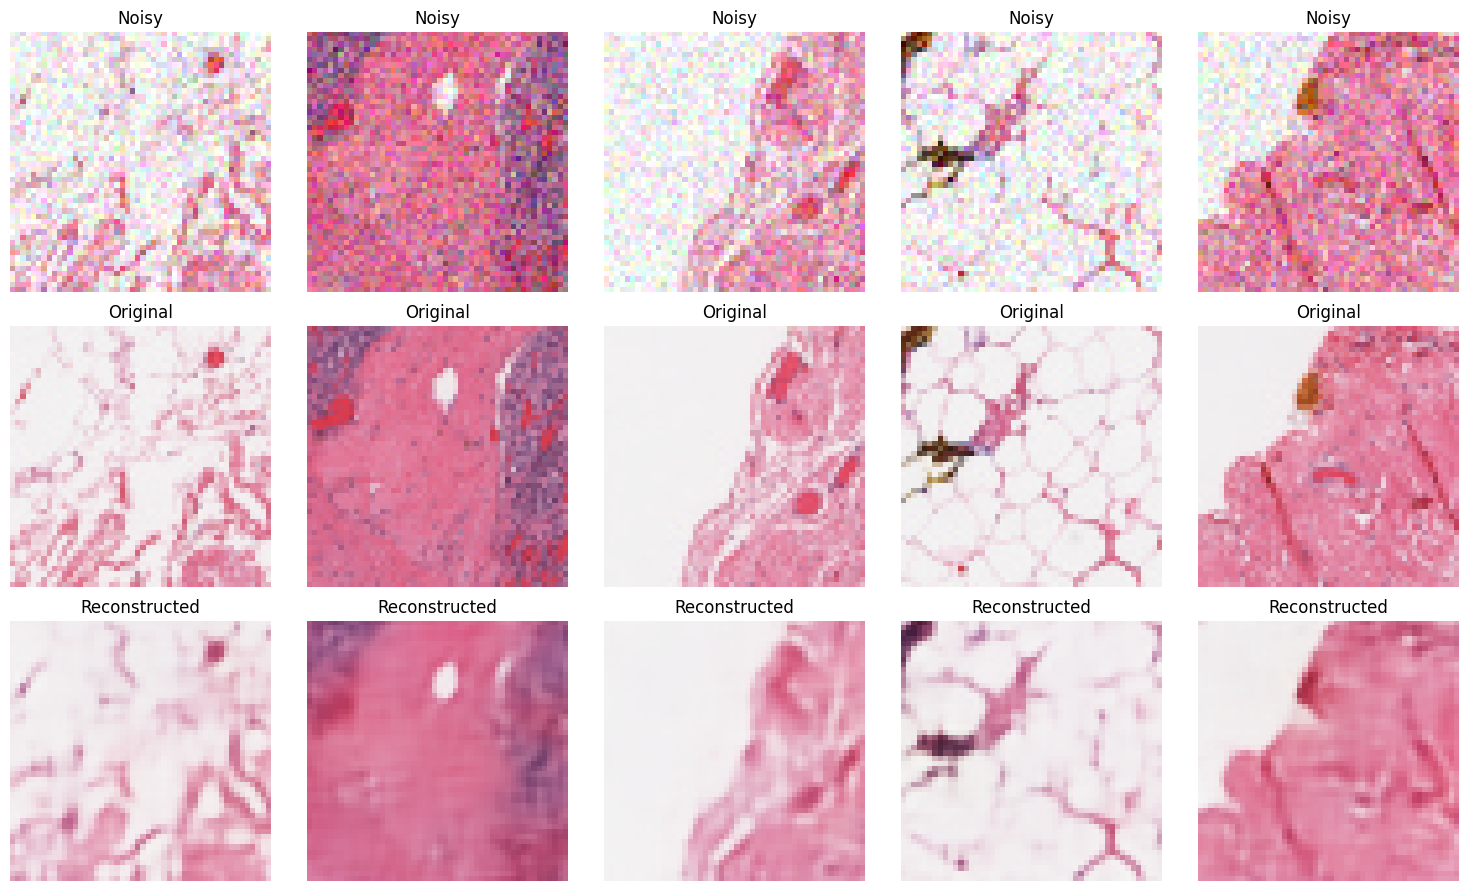

In [ ]:
# ==============================
# 11. Show original / noisy / reconstructed images
# ==============================
n = 5
batch_noisy, batch_clean = next(iter(val_ae_ds))
reconstructed = autoencoder.predict(batch_noisy[:n], verbose=0)

plt.figure(figsize=(15, 9))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(batch_noisy[i].numpy())
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, n, n + i + 1)
    plt.imshow(batch_clean[i].numpy())
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
##extract encoder model part for classifier
encoder = Model(inputs= autoencoder.input,
                outputs= autoencoder.get_layer("encoded_features").output,
                name = "encoder")
encoder.summary()



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_features (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

This stage builds and trains the breast cancer classifier using the pretrained encoder from the autoencoder as a fixed feature extractor. First, the encoder is frozen by setting encoder.trainable = False, which means its learned weights are not updated during initial classifier training. This is done to preserve the useful feature representations already learned during denoising and reconstruction, while allowing the classifier to learn how to use those features for cancer prediction.

A new classifier input is defined and passed through the encoder to produce latent feature maps. Additional convolutional layers are then added to further refine these encoded features and capture more task-specific patterns related to cancer detection. A MaxPooling2D layer reduces spatial dimensions, while GlobalAveragePooling2D replaces flattening to reduce the number of trainable parameters and improve generalisation. The output is then passed through a dense layer with ReLU activation for nonlinear learning, followed by Dropout (0.3) to reduce overfitting. Finally, a dense output layer with sigmoid activation produces the probability that the input image belongs to the cancer class.



## Build Classifier Model with the Encoded image

In [ ]:
encoder.trainable = False

classifier_input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), name="classifier_input")
x = encoder(classifier_input, training=False)

x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation="sigmoid", name="cancer_output")(x)

classifier = Model(classifier_input, output, name="ae_cnn_classifier")

The classifier is compiled using the Adam optimizer with a learning rate of 1e-3, binary crossentropy loss for binary classification, and the metrics accuracy and AUC. Accuracy measures overall correctness, while AUC is especially useful in medical tasks because it evaluates how well the model separates cancerous and non-cancerous samples across thresholds.



In [ ]:
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

classifier.summary()

Model: "ae_cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 7, 7, 128)      │        93,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cancer_output (Dense)           │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,073 (1.23 MB)

 Trainable params: 229,825 (897.75 KB)

 Non-trainable params: 93,248 (364.25 KB)

Since the dataset is imbalanced, class weights are calculated so that errors on the minority class receive greater importance during training. This helps prevent the model from becoming biased toward the majority class. Training is then performed using the training and validation datasets. Two callbacks are used to improve training quality: EarlyStopping monitors validation AUC and stops training if performance no longer improves, while ModelCheckpoint saves the best version of the classifier based on validation AUC. These steps are important because they reduce overfitting and ensure the best-performing model is retained.

Finally, the training history is plotted to show how accuracy and AUC change across epochs for both training and validation sets. These plots help assess whether the classifier is learning effectively, whether it generalises well to unseen data, and whether overfitting begins to occur during training.

Class weights: {0: 0.7097343768354282, 1: 1.6919838977859456}
Epoch 1/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 112s 18ms/step - accuracy: 0.8335 - auc: 0.9118 - loss: 0.3778 - val_accuracy: 0.7930 - val_auc: 0.8854 - val_loss: 0.4763
Epoch 2/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 136s 17ms/step - accuracy: 0.8488 - auc: 0.9280 - loss: 0.3422 - val_accuracy: 0.7862 - val_auc: 0.8957 - val_loss: 0.4917
Epoch 3/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 146s 24ms/step - accuracy: 0.8535 - auc: 0.9326 - loss: 0.3313 - val_accuracy: 0.7449 - val_auc: 0.8882 - val_loss: 0.5810
Epoch 4/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 228s 37ms/step - accuracy: 0.8557 - auc: 0.9353 - loss: 0.3249 - val_accuracy: 0.8207 - val_auc: 0.8889 - val_loss: 0.4117
Epoch 5/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 103s 17ms/step - accuracy: 0.8613 - auc: 0.9387 - loss: 0.3163 - val_accuracy: 0.7846 - val_auc: 0.8943 - val_loss: 0.4777
Epoch 6/15
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 103s 17ms/step - accuracy: 0.8641 - auc: 0.9411 - loss: 0.3102 - val_ac

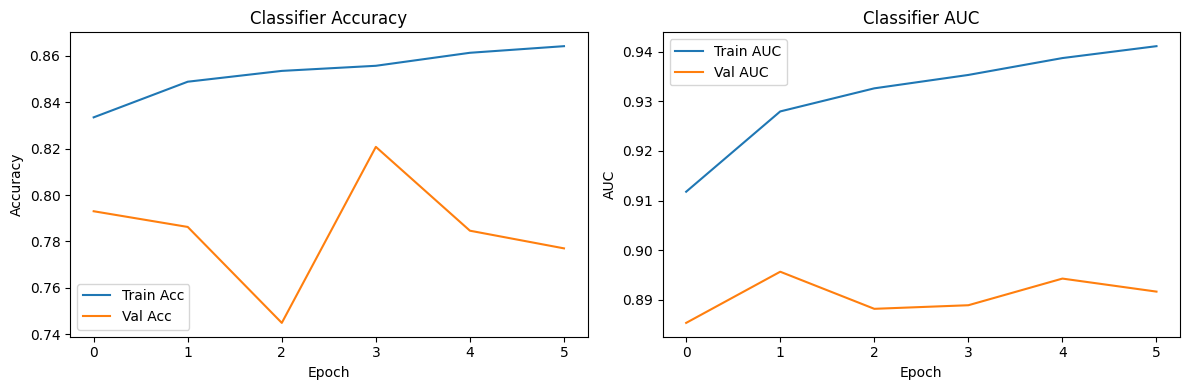

In [ ]:
# ==============================
# 14. Class weights for imbalance
# ==============================
class_counts = train_df["target"].value_counts().to_dict()
total = len(train_df)

class_weight = {
    0: total / (2 * class_counts.get(0, 1)),
    1: total / (2 * class_counts.get(1, 1))
}

print("Class weights:", class_weight)

# ==============================
# 15. Train classifier
# ==============================
clf_callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_classifier.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

history_clf = classifier.fit(
    train_cls_ds,
    validation_data=val_cls_ds,
    epochs=CLASSIFIER_EPOCHS,
    callbacks=clf_callbacks,
    class_weight=class_weight
)

# ==============================
# 16. Plot classifier training
# ==============================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_clf.history["accuracy"], label="Train Acc")
plt.plot(history_clf.history["val_accuracy"], label="Val Acc")
plt.title("Classifier Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_clf.history["auc"], label="Train AUC")
plt.plot(history_clf.history["val_auc"], label="Val AUC")
plt.title("Classifier AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()

plt.tight_layout()
plt.show()

This stage evaluates the classifier on the test set, performs fine-tuning, and then measures the final performance of the improved model. First, the classifier is evaluated before fine-tuning to establish a baseline using the pretrained encoder as a fixed feature extractor. This provides the initial test loss, accuracy, and AUC, showing how well the classifier performs when only the newly added classification layers have been trained.

Next, the encoder is unfrozen by setting encoder.trainable = True, which allows its weights to be updated during further training. This step is called fine-tuning and is done so that the previously learned latent features can be slightly adjusted to better suit the cancer classification task. The model is then recompiled with a much smaller learning rate (1e-5) to ensure that these updates are gradual and do not destroy the useful features already learned during autoencoder training. The classifier is trained again using the same training and validation datasets, along with callbacks and class weights, so that the full network can adapt more specifically to the target problem.

After fine-tuning, the model is evaluated once more on the test set to determine whether performance has improved. Comparing the test accuracy and AUC before and after fine-tuning helps show whether allowing the encoder to learn task-specific features leads to better generalisation. Finally, the model generates prediction probabilities on the test data, which are converted into class labels using a threshold of 0.5. These predictions are summarised using a classification report, which provides precision, recall, and F1-score for both cancer and non-cancer classes. This final step is important because it gives a more detailed understanding of model behaviour, especially in a medical context where correctly identifying cancer cases is more critical than overall accuracy alone.

In [ ]:
# ==============================
# 17. Evaluate on test set (before fine-tuning)
# ==============================
test_loss, test_acc, test_auc = classifier.evaluate(test_cls_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# ==============================
# 18. Fine-tuning
# ==============================
encoder.trainable = True

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

history_finetune = classifier.fit(
    train_cls_ds,
    validation_data=val_cls_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=clf_callbacks,
    class_weight=class_weight
)

# ==============================
# 19. Final evaluation after fine-tuning
# ==============================
test_loss, test_acc, test_auc = classifier.evaluate(test_cls_ds, verbose=1)
print(f"Fine-tuned Test Loss: {test_loss:.4f}")
print(f"Fine-tuned Test Accuracy: {test_acc:.4f}")
print(f"Fine-tuned Test AUC: {test_auc:.4f}")

# ==============================
# 20. Predictions on test set
# ==============================
y_true = test_df["target"].values
y_prob = classifier.predict(test_cls_ds, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))




1337/1337 ━━━━━━━━━━━━━━━━━━━━ 125s 93ms/step - accuracy: 0.7624 - auc: 0.9005 - loss: 0.5225
Test Loss: 0.5225
Test Accuracy: 0.7624
Test AUC: 0.9005
Epoch 1/8
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 112s 17ms/step - accuracy: 0.8442 - auc: 0.9243 - loss: 0.3497 - val_accuracy: 0.7958 - val_auc: 0.9040 - val_loss: 0.4478
Epoch 2/8
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 107s 17ms/step - accuracy: 0.8497 - auc: 0.9287 - loss: 0.3398 - val_accuracy: 0.8117 - val_auc: 0.9046 - val_loss: 0.4197
Epoch 3/8
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 106s 17ms/step - accuracy: 0.8522 - auc: 0.9305 - loss: 0.3357 - val_accuracy: 0.8055 - val_auc: 0.9066 - val_loss: 0.4313
Epoch 4/8
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 107s 17ms/step - accuracy: 0.8532 - auc: 0.9315 - loss: 0.3331 - val_accuracy: 0.8302 - val_auc: 0.9090 - val_loss: 0.3881
Epoch 5/8
6042/6042 ━━━━━━━━━━━━━━━━━━━━ 110s 18ms/step - accuracy: 0.8537 - auc: 0.9326 - loss: 0.3305 - val_accuracy: 0.8168 - val_auc: 0.9077 - val_loss: 0.4093
Epoch 6/8
6042/6042 ━━━━━━━━━

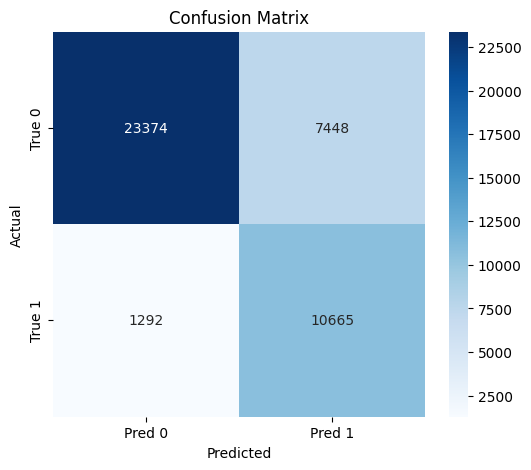

In [ ]:
# ==============================
# 21. Confusion Matrix
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

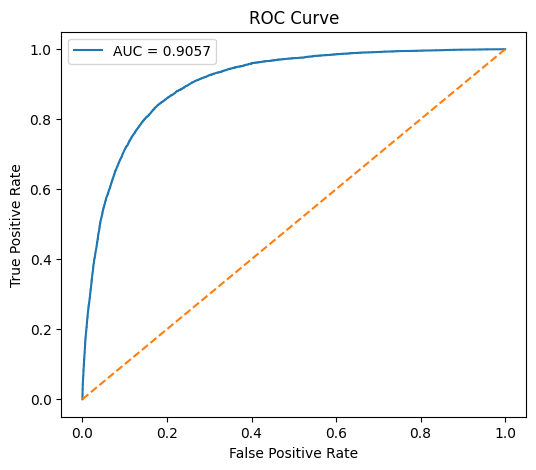

In [ ]:
# ==============================
# 22. ROC Curve
# ==============================
auc_score = roc_auc_score(y_true, y_prob)
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Latent Space Graph USing TNSE

This step visualises the latent feature space learned by the encoder using t-SNE (t-distributed Stochastic Neighbor Embedding). First, the encoder is used to extract latent features from the dataset, which represent compressed and meaningful information about each image. Since t-SNE is computationally expensive, a subset of up to 3000 samples is randomly selected to ensure efficient processing. These high-dimensional latent features are then reduced to two dimensions using t-SNE, which preserves the local structure of the data and allows similar samples to be positioned close together in the visualisation.

The resulting 2D representation is plotted using a scatter plot, where each point corresponds to an image and is coloured based on its class label (cancerous or non-cancerous). This visualisation helps assess how well the encoder has learned to separate the two classes in the latent space. Ideally, distinct clusters for each class indicate that the encoder has captured meaningful features that can improve classification performance. This step is important because it provides an intuitive, visual validation of the quality of the learned representations beyond numerical metrics.

Latent feature shape: (42779, 6272)
Latent labels shape: (42779,)


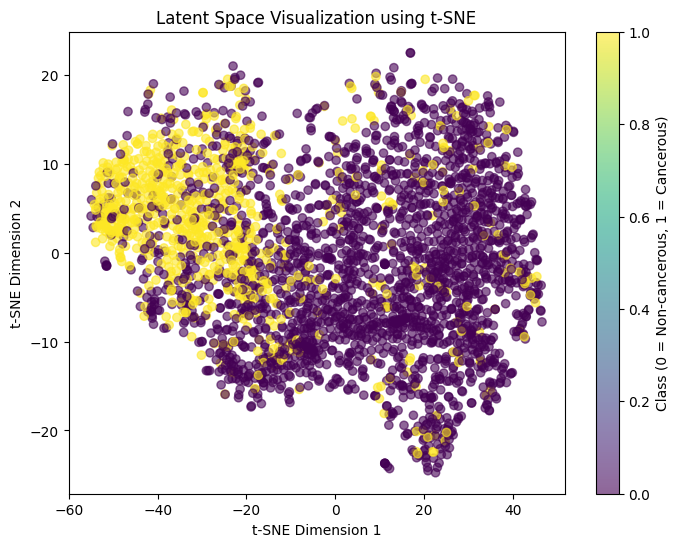

In [ ]:
# ==============================
# 24. Latent space extraction
# ==============================
def extract_latent_features(model_encoder, dataset):
    latent_features = []
    labels = []

    for batch_images, batch_labels in dataset:
        encoded_batch = model_encoder.predict(batch_images, verbose=0)
        encoded_batch = encoded_batch.reshape(encoded_batch.shape[0], -1)
        latent_features.append(encoded_batch)
        labels.append(batch_labels.numpy())

    latent_features = np.vstack(latent_features)
    labels = np.concatenate(labels)

    return latent_features, labels

latent_features, latent_labels = extract_latent_features(encoder, test_cls_ds)

print("Latent feature shape:", latent_features.shape)
print("Latent labels shape:", latent_labels.shape)
## Latent space graph usig TNSE
# ==============================
# 26. t-SNE latent space graph
#    Use a subset because t-SNE is slow
# ==============================


max_tsne_samples = min(3000, latent_features.shape[0])
indices = np.random.choice(latent_features.shape[0], max_tsne_samples, replace=False)

latent_subset = latent_features[indices]
label_subset = latent_labels[indices]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
latent_2d_tsne = tsne.fit_transform(latent_subset)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latent_2d_tsne[:, 0],
    latent_2d_tsne[:, 1],
    c=label_subset,
    alpha=0.6
)
plt.title("Latent Space Visualization using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="Class (0 = Non-cancerous, 1 = Cancerous)")
plt.show()


## Save Models

In [ ]:
# ==============================
# 23. Save models
# ==============================
autoencoder.save("breast_autoencoder.keras")
encoder.save("breast_encoder.keras")
classifier.save("breast_cancer_classifier.keras")

print("Models saved successfully.")

Models saved successfully.


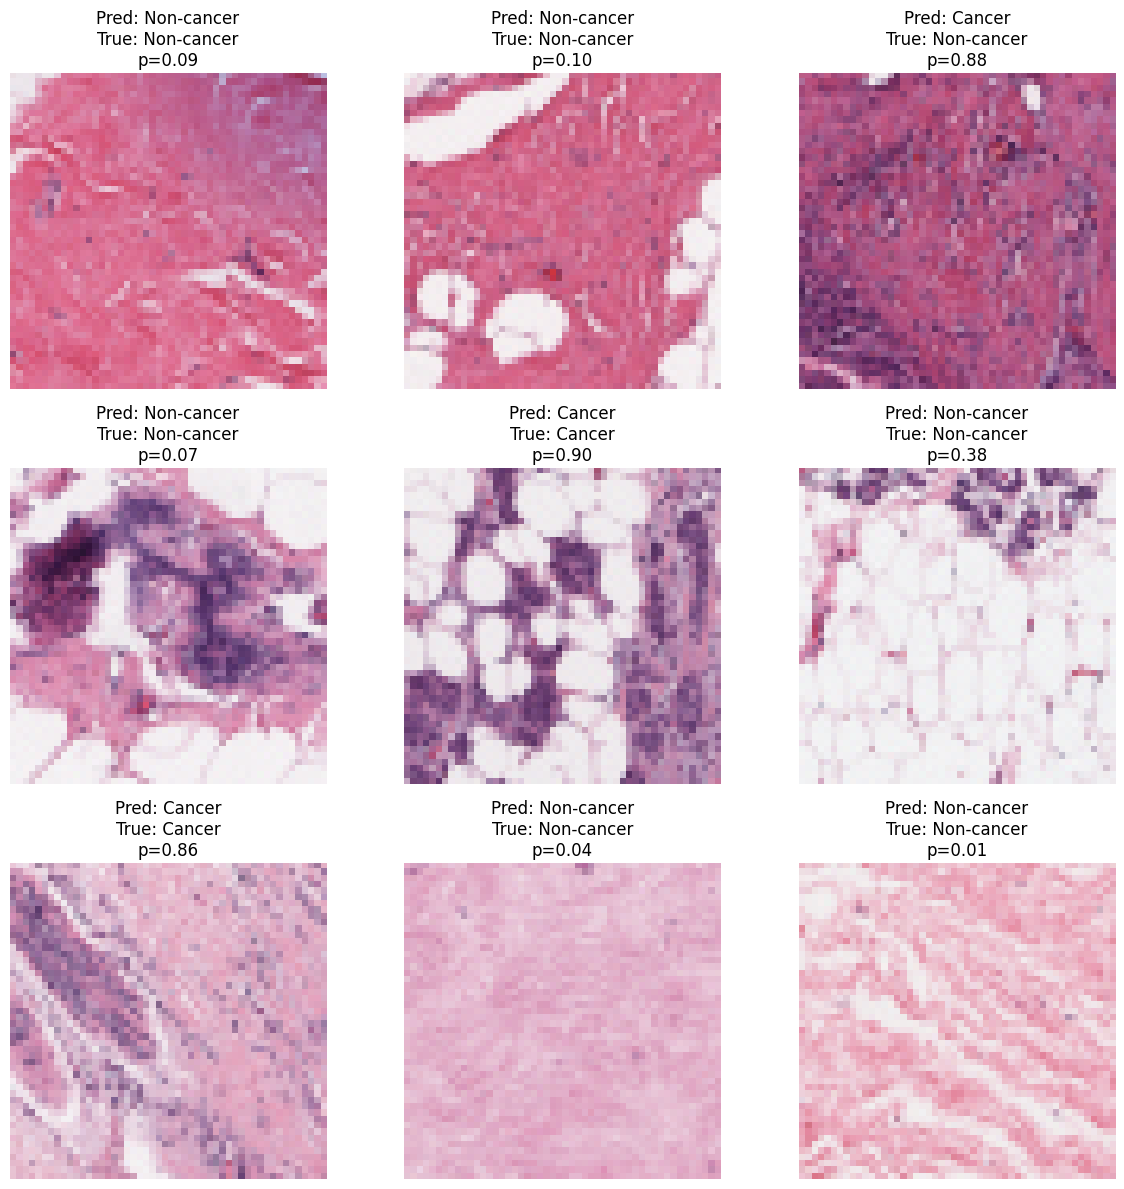

In [ ]:
# ==============================
# 29. Prediction grid
# ==============================
def plot_prediction_grid(df, model, n=9, img_height=50, img_width=50):
    sample_df = df.sample(n, random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(12, 12))

    for i, row in sample_df.iterrows():
        image_path = row["filepath"]
        true_label = row["target"]

        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [img_height, img_width])
        img = tf.cast(img, tf.float32) / 255.0

        img_batch = tf.expand_dims(img, axis=0)
        prob = model.predict(img_batch, verbose=0)[0][0]
        pred_class = 1 if prob >= 0.5 else 0

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"Pred: {'Cancer' if pred_class == 1 else 'Non-cancer'}\n"
            f"True: {'Cancer' if true_label == 1 else 'Non-cancer'}\n"
            f"p={prob:.2f}"
        )

    plt.tight_layout()
    plt.show()

plot_prediction_grid(test_df, classifier, n=9)